### 1: Write the code for Logistic regression with 2 features, 100 samples and 2 classes (by scratch and visualize the result.)

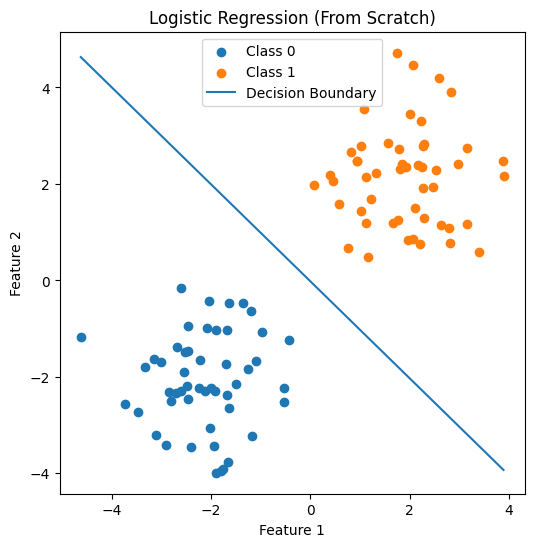

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# STEP 1: Create a simple dataset (100 samples)
# --------------------------------------------------

np.random.seed(42)   # for same random results every time

n_samples = 100

# First class (label = 0)
# Points around (-2, -2)
X_class0 = np.random.randn(n_samples//2, 2) + np.array([-2, -2])
y_class0 = np.zeros((n_samples//2, 1))

# Second class (label = 1)
# Points around (2, 2)
X_class1 = np.random.randn(n_samples//2, 2) + np.array([2, 2])
y_class1 = np.ones((n_samples//2, 1))

# Combine both classes into one dataset
X = np.vstack((X_class0, X_class1))   # shape (100, 2)
y = np.vstack((y_class0, y_class1))   # shape (100, 1)

# --------------------------------------------------
# STEP 2: Initialize weights and bias
# --------------------------------------------------

n_features = X.shape[1]   # here = 2 features

W = np.zeros((n_features, 1))   # weights (2x1)
b = 0                           # bias

learning_rate = 0.1
epochs = 1000

# --------------------------------------------------
# STEP 3: Define sigmoid function
# --------------------------------------------------

def sigmoid(z):
    """
    Converts any value into range (0,1)
    Used to represent probability
    """
    return 1 / (1 + np.exp(-z))

# --------------------------------------------------
# STEP 4: Training using Gradient Descent
# --------------------------------------------------

for i in range(epochs):

    # ----- Forward pass -----
    # Linear equation: z = W.X + b
    z = np.dot(X, W) + b
    
    # Apply sigmoid to get probability
    y_pred = sigmoid(z)

    # ----- Compute gradients -----
    m = X.shape[0]   # number of samples

    # derivative of loss w.r.t weights
    dW = (1/m) * np.dot(X.T, (y_pred - y))

    # derivative of loss w.r.t bias
    db = (1/m) * np.sum(y_pred - y)

    # ----- Update weights -----
    W = W - learning_rate * dW
    b = b - learning_rate * db

# --------------------------------------------------
# STEP 5: Visualize data + decision boundary
# --------------------------------------------------

plt.figure(figsize=(6,6))

# Plot class 0
plt.scatter(X_class0[:, 0], X_class0[:, 1], label="Class 0")

# Plot class 1
plt.scatter(X_class1[:, 0], X_class1[:, 1], label="Class 1")

# Decision boundary line:
# W1*x1 + W2*x2 + b = 0
# => x2 = -(W1*x1 + b)/W2

x_values = np.array([X[:,0].min(), X[:,0].max()])
y_values = -(W[0] * x_values + b) / W[1]

plt.plot(x_values, y_values, label="Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression (From Scratch)")
plt.legend()
plt.show()

### 2) Write the program for MLP solving XOR problem.

## scratch

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

def fit(data, target, hidden_n=2, lr=0.1, epochs=5000):
    n_samples, n_features = data.shape

    history = defaultdict(list)

    W1 = np.random.randn(hidden_n,n_features)
    b1 = np.zeros((hidden_n,1))

    W2 = np.random.randn(1,hidden_n)
    b2 = np.zeros((1, 1))


    for epoch in range(epochs):

        target = target.reshape(1, -1)

        z1 = np.dot(W1,data.T) + b1
        a1 = sigmoid(z1)

        z2 = np.dot(W2,a1) + b2
        a2 = sigmoid(z2)

        loss = -np.sum(target*np.log10(a2) + (1-target)*np.log10(1-a2))
        # print("a2",a2.shape,"target",target.shape)
        # print("a1",a1.shape,"W1",W1.shape)
        # print("W2",W2.shape)

        dz2 = a2 - target
        dW2 = np.dot(dz2,a1.T)
        db2 = np.sum(dz2, axis=1, keepdims=True)


        dz1 = np.dot(dz2.T,W2).T * sigmoid_deriv(z1)
        dW1 = np.dot(dz1,data)
        db1 = np.sum(dz1, axis=1, keepdims=True)

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        history["W1"].append(W1.copy())
        history["W2"].append(W2.copy())
        history["b1"].append(b1.copy())
        history["b2"].append(b2.copy())
        history["loss"].append(loss.copy())

    return W1, b1, W2, b2, history


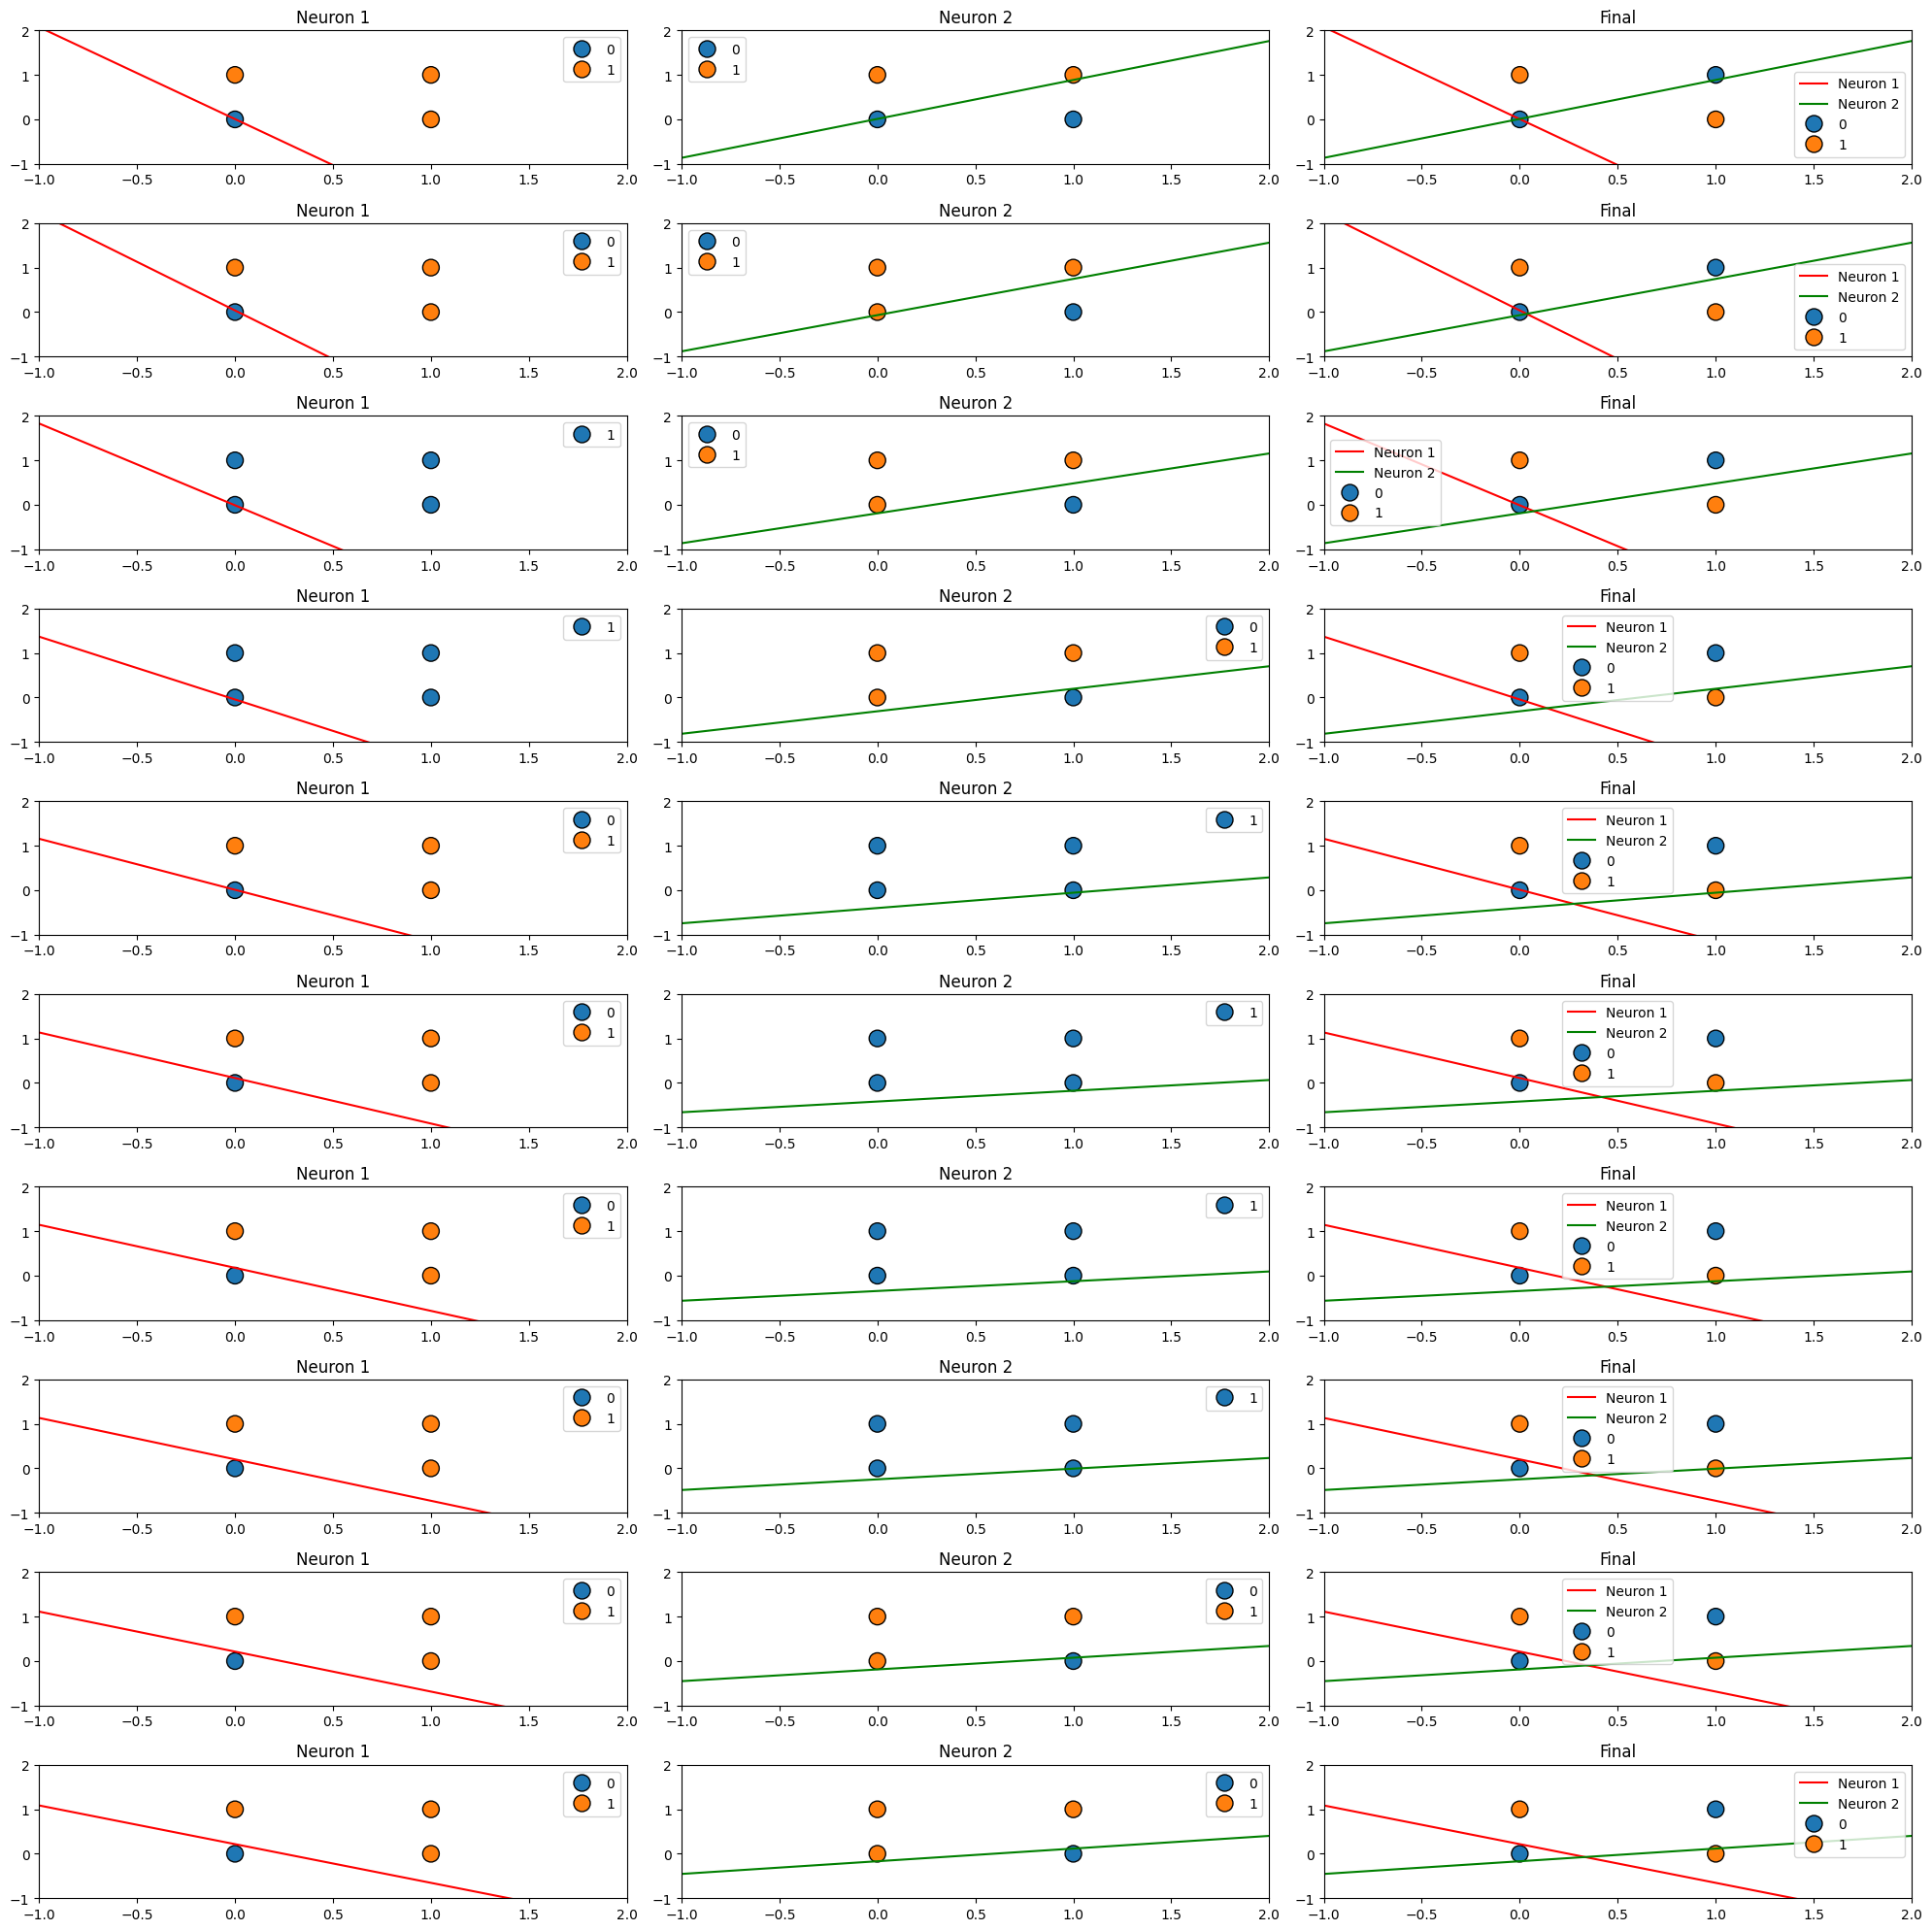

In [5]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])
epochs = 1000

W1,b1,W2,b2,history = fit(X,y,hidden_n=2,lr=0.1,epochs=epochs)
plt.figure(figsize=(20,20))
plot_id = 1
data = X
x1_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)

for i in range(0, epochs, 100):
    W1 = history["W1"][i]
    b1 = history["b1"][i]
    W2 = history["W2"][i]
    b2 = history["b2"][i]

    a1 = sigmoid(np.dot(W1,data.T) + b1)
    h1 = a1[0,:]
    h2 = a1[1,:]
    h1_w1, h1_w2 = W1[0,:]
    h2_w1, h2_w2 = W1[1,:]

    y_h1 = - (np.dot(x1_vals,h1_w1) + b1[0,:])/h1_w2
    y_h2 = - (np.dot(x1_vals,h2_w1) + b1[1,:])/h2_w2

    a2 = sigmoid(np.dot(W2,a1) + b2)
    Z = (a2 > 0.5).astype(int).reshape(y.shape)
    h1 = (h1 > 0.5).astype(int).reshape(y.shape)
    h2 = (h2 > 0.5).astype(int).reshape(y.shape)

    plt.subplot(10,3,plot_id)
    plt.title("Neuron 1")
    plt.plot(x1_vals, y_h1, color="red")
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=h1, s=150, edgecolors='k')
    plt.xlim(-1,2)
    plt.ylim(-1,2)
    plot_id += 1

    plt.subplot(10,3,plot_id)
    plt.title("Neuron 2")
    plt.plot(x1_vals, y_h2, color="green")
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=h2, s=150, edgecolors='k')
    plt.xlim(-1,2)
    plt.ylim(-1,2)
    plot_id += 1

    plt.subplot(10,3,plot_id)
    plt.title("Final")
    plt.plot(x1_vals, y_h1, color="red",label = "Neuron 1")
    plt.plot(x1_vals, y_h2, color="green",label = "Neuron 2")
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, s=150, edgecolors='k')
    plt.xlim(-1,2)
    plt.ylim(-1,2)
    plot_id += 1

plt.tight_layout()
plt.show()

### 3) Write a program to find the value of activation functions and their derivatives (sigmoid, softmax, ReLu, leaky ReLu, tanh)

## scratch

Softmax Input: [1. 2. 3.]
Softmax Output: [0.09003057 0.24472847 0.66524096]
Softmax Derivative (Jacobian Matrix):
 [[ 0.08192507 -0.02203304 -0.05989202]
 [-0.02203304  0.18483645 -0.1628034 ]
 [-0.05989202 -0.1628034   0.22269543]]


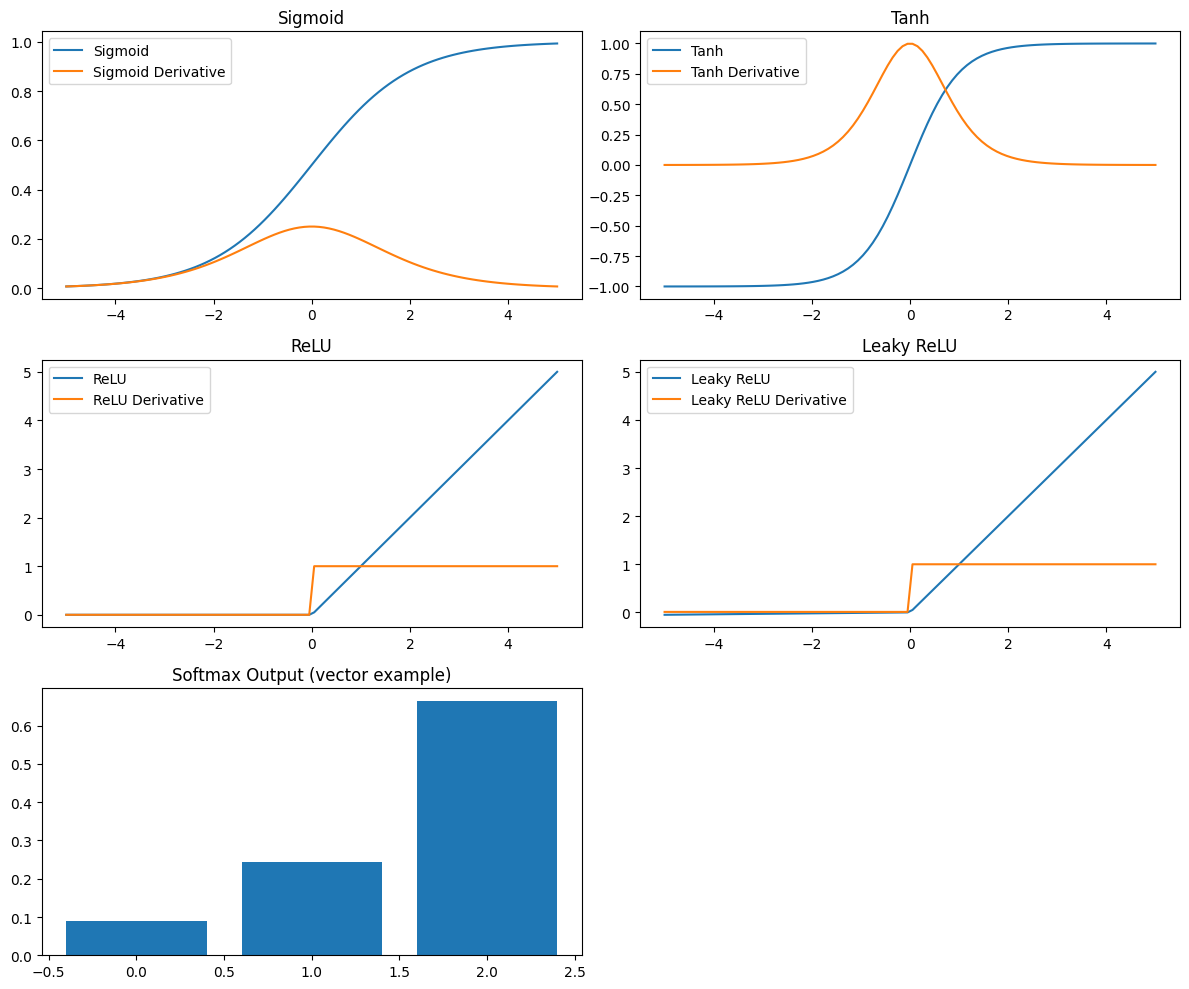

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# STEP 1: Define input values
# --------------------------------------------------
# We take values from -5 to 5 for plotting
x = np.linspace(-5, 5, 100)

# --------------------------------------------------
# STEP 2: Define Activation Functions + Derivatives
# --------------------------------------------------

# 🔹 Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


# 🔹 Tanh
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2


# 🔹 ReLU
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)


# 🔹 Leaky ReLU
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)


# 🔹 Softmax (vector input)
def softmax(x):
    exp_x = np.exp(x - np.max(x))   # stability trick
    return exp_x / np.sum(exp_x)

# derivative of softmax is Jacobian matrix
def softmax_derivative(x):
    s = softmax(x).reshape(-1,1)
    return np.diagflat(s) - np.dot(s, s.T)


# --------------------------------------------------
# STEP 3: Compute values
# --------------------------------------------------

sig = sigmoid(x)
sig_d = sigmoid_derivative(x)

tanh_v = tanh(x)
tanh_d = tanh_derivative(x)

relu_v = relu(x)
relu_d = relu_derivative(x)

leaky_v = leaky_relu(x)
leaky_d = leaky_relu_derivative(x)

# For softmax, we use a sample vector
softmax_input = np.array([1.0, 2.0, 3.0])
softmax_val = softmax(softmax_input)
softmax_der = softmax_derivative(softmax_input)

# --------------------------------------------------
# STEP 4: Print Softmax result (matrix derivative)
# --------------------------------------------------

print("Softmax Input:", softmax_input)
print("Softmax Output:", softmax_val)
print("Softmax Derivative (Jacobian Matrix):\n", softmax_der)

# --------------------------------------------------
# STEP 5: Plot all functions and derivatives
# --------------------------------------------------

plt.figure(figsize=(12,10))

# Sigmoid
plt.subplot(3,2,1)
plt.plot(x, sig, label="Sigmoid")
plt.plot(x, sig_d, label="Sigmoid Derivative")
plt.title("Sigmoid")
plt.legend()

# Tanh
plt.subplot(3,2,2)
plt.plot(x, tanh_v, label="Tanh")
plt.plot(x, tanh_d, label="Tanh Derivative")
plt.title("Tanh")
plt.legend()

# ReLU
plt.subplot(3,2,3)
plt.plot(x, relu_v, label="ReLU")
plt.plot(x, relu_d, label="ReLU Derivative")
plt.title("ReLU")
plt.legend()

# Leaky ReLU
plt.subplot(3,2,4)
plt.plot(x, leaky_v, label="Leaky ReLU")
plt.plot(x, leaky_d, label="Leaky ReLU Derivative")
plt.title("Leaky ReLU")
plt.legend()

# Softmax (bar plot)
plt.subplot(3,2,5)
plt.bar(range(len(softmax_val)), softmax_val)
plt.title("Softmax Output (vector example)")

# leave last subplot empty
plt.subplot(3,2,6)
plt.axis('off')

plt.tight_layout()
plt.show()

## 4) Construct a neural network with 1 input, 2 hidden and 1 output layer and also write the logic for the weight updation for this (hard coded only)

## Looping

In [7]:
import numpy as np

# --------------------------------------------------
# STEP 1: Define Sigmoid and its derivative
# --------------------------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(a):
    return a * (1 - a)   # a = sigmoid(x)

# --------------------------------------------------
# STEP 2: Input and target (hard-coded example)
# --------------------------------------------------
x = 1.0        # single input
y = 1.0        # target output

# --------------------------------------------------
# STEP 3: Initialize weights and biases (manually)
# --------------------------------------------------

# input → hidden weights
w1 = 0.5   # weight to hidden neuron 1
w2 = -0.4  # weight to hidden neuron 2

b1 = 0.1   # bias for h1
b2 = -0.2  # bias for h2

# hidden → output weights
w3 = 0.8   # from h1 → output
w4 = -0.6  # from h2 → output

b3 = 0.05  # output bias

learning_rate = 0.1

# --------------------------------------------------
# STEP 4: FORWARD PASS
# --------------------------------------------------

# Hidden layer
z1 = x * w1 + b1
h1 = sigmoid(z1)

z2 = x * w2 + b2
h2 = sigmoid(z2)

# Output layer
z3 = h1 * w3 + h2 * w4 + b3
y_hat = sigmoid(z3)

print("Predicted output before training:", y_hat)

# --------------------------------------------------
# STEP 5: ERROR (Binary Cross Entropy derivative)
# --------------------------------------------------
# derivative of loss wrt output activation
dL_dyhat = y_hat - y

# --------------------------------------------------
# STEP 6: BACKPROPAGATION
# --------------------------------------------------

# ---- Output layer gradients ----
dyhat_dz3 = sigmoid_derivative(y_hat)

dL_dz3 = dL_dyhat * dyhat_dz3

# gradients for output weights
dL_dw3 = dL_dz3 * h1
dL_dw4 = dL_dz3 * h2
dL_db3 = dL_dz3

# ---- Hidden layer gradients ----
# backprop into hidden neurons

dL_dh1 = dL_dz3 * w3
dL_dh2 = dL_dz3 * w4

dh1_dz1 = sigmoid_derivative(h1)
dh2_dz2 = sigmoid_derivative(h2)

dL_dz1 = dL_dh1 * dh1_dz1
dL_dz2 = dL_dh2 * dh2_dz2

# gradients for input→hidden weights
dL_dw1 = dL_dz1 * x
dL_dw2 = dL_dz2 * x

dL_db1 = dL_dz1
dL_db2 = dL_dz2

# --------------------------------------------------
# STEP 7: UPDATE WEIGHTS (HARD CODED)
# --------------------------------------------------

w3 = w3 - learning_rate * dL_dw3
w4 = w4 - learning_rate * dL_dw4
b3 = b3 - learning_rate * dL_db3

w1 = w1 - learning_rate * dL_dw1
w2 = w2 - learning_rate * dL_dw2
b1 = b1 - learning_rate * dL_db1
b2 = b2 - learning_rate * dL_db2

# --------------------------------------------------
# STEP 8: FORWARD PASS AGAIN (after update)
# --------------------------------------------------

z1 = x * w1 + b1
h1 = sigmoid(z1)

z2 = x * w2 + b2
h2 = sigmoid(z2)

z3 = h1 * w3 + h2 * w4 + b3
y_hat_new = sigmoid(z3)

print("Predicted output after 1 update:", y_hat_new)

Predicted output before training: 0.5875675609953711
Predicted output after 1 update: 0.5915516875402799


## Matrics

In [8]:
import numpy as np

# --------------------------------------------------
# STEP 1: Activation functions
# --------------------------------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)   # 'a' is sigmoid(z)

# --------------------------------------------------
# STEP 2: Input and Target
# --------------------------------------------------
X = np.array([[1.0]])    # shape (1,1) → 1 sample, 1 feature
Y = np.array([[1.0]])    # shape (1,1)

# --------------------------------------------------
# STEP 3: Initialize weights and biases (MATRIX form)
# --------------------------------------------------

# Input → Hidden (1×2)
W1 = np.array([[0.5, -0.4]])
b1 = np.array([[0.1, -0.2]])

# Hidden → Output (2×1)
W2 = np.array([[0.8],
               [-0.6]])
b2 = np.array([[0.05]])

learning_rate = 0.1

# --------------------------------------------------
# STEP 4: FORWARD PASS (Matrix form)
# --------------------------------------------------

# Hidden layer
Z1 = np.dot(X, W1) + b1       # (1x1)*(1x2) = (1x2)
A1 = sigmoid(Z1)

# Output layer
Z2 = np.dot(A1, W2) + b2      # (1x2)*(2x1) = (1x1)
A2 = sigmoid(Z2)

print("Output before training:", A2)

# --------------------------------------------------
# STEP 5: BACKPROPAGATION (Matrix)
# --------------------------------------------------

# Output layer error
dZ2 = A2 - Y                        # (1x1)

# gradients for W2 and b2
dW2 = np.dot(A1.T, dZ2)             # (2x1)
db2 = dZ2                           # (1x1)

# Hidden layer error
dA1 = np.dot(dZ2, W2.T)             # (1x2)
dZ1 = dA1 * sigmoid_derivative(A1)  # (1x2)

# gradients for W1 and b1
dW1 = np.dot(X.T, dZ1)              # (1x2)
db1 = dZ1                           # (1x2)

# --------------------------------------------------
# STEP 6: UPDATE WEIGHTS (Matrix form)
# --------------------------------------------------

W2 = W2 - learning_rate * dW2
b2 = b2 - learning_rate * db2

W1 = W1 - learning_rate * dW1
b1 = b1 - learning_rate * db1

# --------------------------------------------------
# STEP 7: FORWARD PASS AGAIN (after update)
# --------------------------------------------------

Z1 = np.dot(X, W1) + b1
A1 = sigmoid(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)

print("Output after 1 update:", A2)

Output before training: [[0.58756756]]
Output after 1 update: [[0.60393698]]
